# 🌿 Cost–Benefit Analysis of Increasing Canopy Cover

This notebook aims to assess the **cost–benefit relationship of agroforestry systems**, focusing on their impact on the **value chain of tropical perennial crops** — specifically through the **ecosystem service of microclimate regulation**.

Agroforestry provides multiple ecosystem services, including: moisture retention, protection from intense sunlight, and humidity regulation. In this analysis, we concentrate on the **cooling benefit** of shade trees. We model this cooling effect as a **reduction in maximum daily temperature**, which is assumed to be a function of **canopy cover** — used here as a proxy for shade level.

The goal is to quantify how changes in canopy cover affect crop yields through **climate hazard modification**, and to assess whether the **costs of implementing shading measures** are justified by their **benefits in yield protection**.

- **Hazards**: Mean yearly **Vapour Pressure Deficit (VPD)**  Mean yearly **maximum temperature (TASMAX)**

- **Exposure**: Average crop yield (or production) per location

- **Impact Function**: Estimated **relative yield reduction** as a function of the above hazards

From a technical viewpoint, the idea is that the condition of the ecosystem service (indicated by the biodiversity indicator) influences the hazard, exposure, and impact function.

- **Biodiversity Link**: The **ecosystem condition**, reflected by **canopy cover**, modifies the hazard (e.g., via cooling) and potentially the impact.

We also incorporate uncertainty parameters such as adaptation cooling effect, cost assumptions, and canopy cover scenarios to produce a **distribution of risk and cost–benefit outcomes**.

The valubel outcome of such a 

The notebook contains configurable parameters such as country, crop type, and biophysical assumptions (e.g. cooling curve). Although this notebook focuses on microclimate regulation, the same structure can be adapted to other ecosystem services. For instance, canopy cover could influence:
- Humidity (linking to VPD)
- Soil retention (linking to erosion/flooding)
- Pollination or pest control (via biodiversity)

This notebook is developed using the old cost-benefot module to get an idea how canopy cover could be incoorporate to asses cost-benfit in the aspect of the value-chain. FOr the future develop of the cost-benfit or other ad-hoc development one could consider . 

This note complements the notebook looking at the rsik to the biodiversity and ecosystem sercie itseld. A third intention is too couple the too to see how the harm to ecossytem service results in a risk on the value-cahin.


Uncertainty parameters 
- 
- Possible in next section e.g., canopy cover 

*Data sources (make table and give options, e.g., calibrated impact function)*

*References (to be added later)*


## Step 1 - Decide country, crop and hazard

In [1]:
from pathlib import Path
import os

# Define output and input directories (make clean directories for UNU)
INPUT_DIR = Path(os.path.join(os.getcwd(), '..', 'data')).resolve()
OUTPUT_DIR = Path(os.path.join(os.getcwd(), '..', 'output')).resolve()

# Decide country code based on the bounding box
country = 'MEX' # 'MEX' for Mexico, 'GTM' for Guatemala, and 'DOM' for Dominican Republic

# Decide the crop
crop = 'coffee' # 'coffee' for coffee, 'cacao' for cacao, and 'banana' for banana

# Define the hazard type
hazard_type = 'VPD'

## Step 2 - Exposure

**Crop Production and Plantation Area (2020)**

We derive crop production (in tonnes) per grid cell using the 2020 MAPSPAM dataset.  

*Description*
- We also extract the plantation area per cell for each crop. Used to calculate the cost of increasing the canopy cover (%) for the site.
- The data (raster file of resolution 10 km x 10 km) is available at: [https://mapspam.info](https://mapspam.info)  
    - For more details, see the [Read Me](https://www.dropbox.com/scl/fi/z468wh0d8abfohol991r5/Readme.txt?rlkey=el1w3zeykz909aadrx2xuck36&e=1&dl=0)
- Grid points with zero production are removed from the dataset.
- Note: We work with grid-level production estimates due to lack of precise plantation coordinates. For future applications, users may upload their own exposure file with site-specific geometries (polygons or points), including canopy cover and tree species composition.


In [2]:
from utils_cb import get_crop_prod_exposure, COUNTRY_BOUNDS, FILES_CROP_PROD, FILES_CROP_HARVEST

# Get the exposure object for the given crop and bounding box
exp = get_crop_prod_exposure(file = INPUT_DIR / FILES_CROP_PROD[crop], # file path to the crop production data
                                             bbox = COUNTRY_BOUNDS[country], # bounding box for the country
                                            hazard_type = hazard_type, # hazard type (e.g., 'VPD', 'Tmax', etc.)
                                            harvest_area_file= INPUT_DIR / FILES_CROP_HARVEST[crop] # file path to the harvest area data
                                            ) 

Look at the exposure data. 

As shown the majority of production is concentrated in southern Mexico—particularly in regions characterized by favorable climate and topography for coffee. 

+----+---------+------------+---------------------+------------------------------------------------+
|    |   value |   impf_VPD |   harvest_area (ha) | geometry                                       |
|----+---------+------------+---------------------+------------------------------------------------|
|  0 |     0.1 |          1 |                 1   | POINT (-100.9583333333513 23.87500000001502)   |
|  1 |     0.1 |          1 |                 1   | POINT (-100.87500000001799 23.87500000001502)  |
|  2 |     0.1 |          1 |                 1   | POINT (-100.79166666668468 23.87500000001502)  |
|  3 |     0.6 |          1 |                 5.9 | POINT (-100.9583333333513 23.791666666681706)  |
|  4 |     0.1 |          1 |                 1   | POINT (-100.70833333335136 23.791666666681706) |
+----+---------+------------+---------------------+------------------------------------------------+


<GeoAxes: >

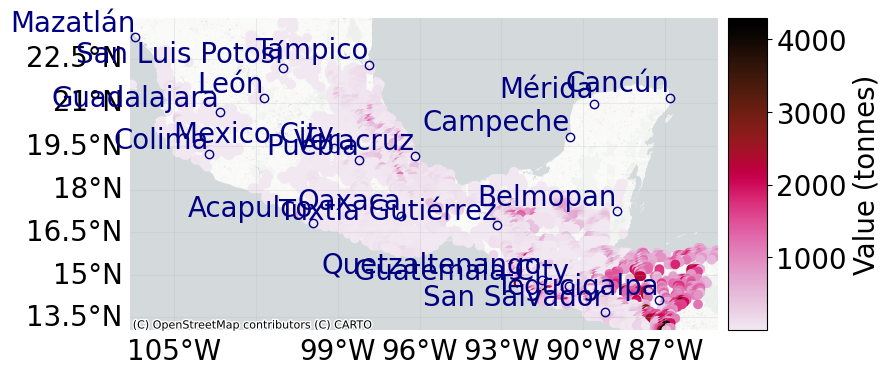

In [3]:
from tabulate import tabulate

# Print and plot the exposure object
print(tabulate(exp.gdf.head(), headers='keys', tablefmt='psql'))

# Plot the exposure object
exp.plot_basemap()

### Canopy Cover Data

Download canopy cover data (10 × 10 m resolution raster) from:  
[https://earthenginepartners.appspot.com/science-2013-global-forest/download_v1.7.html](https://earthenginepartners.appspot.com/science-2013-global-forest/download_v1.7.html)

We will use this data to ,ake a canopy cover estimate for each site location if not given in the exposure file.

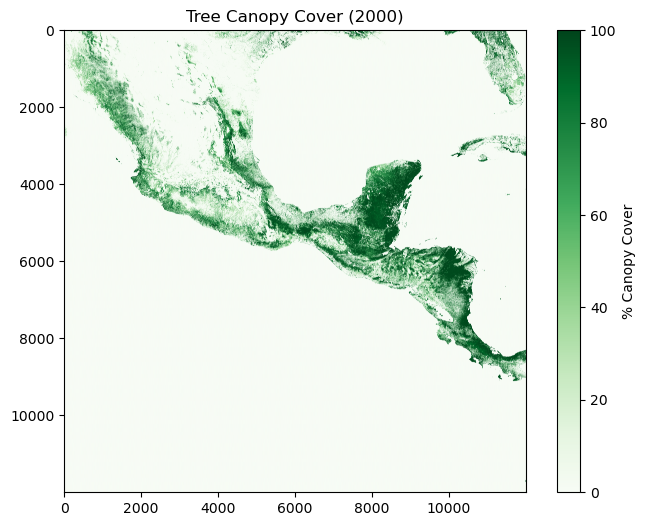

In [4]:
from utils_cb import merge_rasters, downsample_raster, add_canopy_cover_to_exposure
import matplotlib.pyplot as plt

# --- CONFIG ---
canopy_tif_path = INPUT_DIR / "merged_treecover2000.tif" # Path to the canopy raster file


# Load the merged raster file
if not canopy_tif_path.exists():
    print("Merged file not found. Creating...")
    merge_rasters(input_dir = INPUT_DIR / "Hansen_TreeCover", # input directory containing the raster tiles
                 output_path = canopy_tif_path # output path for the merged raster
                    )

# Plot
downsampling_factor = 10  # or None for full resolution for faster plotting
plt.figure(figsize=(8, 6))
plt.imshow(downsample_raster(canopy_tif_path, downsampling_factor), 
           cmap='Greens')
plt.colorbar(label='% Canopy Cover')
title = f"Tree Canopy Cover (2000)"
plt.title(title)
plt.show()

We add the average canopy cover by creating a buffer zone aorund the site.

In [5]:
# Add canopy cover to the exposure object
buffer_m = 500  # Buffer in meters for the exposure points
exp = add_canopy_cover_to_exposure(exp, canopy_tif_path, buffer_m)
print(tabulate(exp.gdf[["value", "canopy_cover", "harvest_area (ha)"]].head(), headers='keys', tablefmt='psql'))

+----+---------+----------------+---------------------+
|    |   value |   canopy_cover |   harvest_area (ha) |
|----+---------+----------------+---------------------|
|  4 |     0.1 |        1       |                 1   |
|  7 |     0.6 |       12.1688  |                 7   |
|  8 |     0.7 |       12.6     |                 7.2 |
| 17 |     0.3 |        4.81111 |                 4.9 |
| 28 |     0.6 |       18.0494  |                 5.8 |
+----+---------+----------------+---------------------+


## Step 3 – Get the Hazard

**VPD – Vapour Pressure Deficit**

We model Vapour Pressure Deficit (VPD) as a climate hazard, following the method used in this study:  
[https://www.nature.com/articles/s43016-022-00614-8#MOESM1](https://www.nature.com/articles/s43016-022-00614-8#MOESM1)
The study provides a vulnerability curve linking mean VPD during the growing season to yield impacts.

We calculate the mean VPD over the crop-specific growing season:
- **Mexico:** June to December  
- **Guatemala:** June to February

*Data Sources – ERA5 Daily Climate Data*

To derive VPD, we use:
- [Daily Average Temperature](https://data.isimip.org/datasets/89ea5897-ce44-4e7c-87ac-c8ea40419f94/)
- [Daily Precipitation](https://data.isimip.org/datasets/5df317c0-4f9c-4755-9a9e-5c6f7705faad/)

**Note:** ERA5 data has a spatial resolution of approximately 25–28 km.


In [6]:
from utils_cb import load_isimip_multi_and_subset

# Load ISIMIP data for tas and hurs
tas_files = sorted(INPUT_DIR.glob("Isimip/20crv3-era5_obsclim_tas_global_daily_*.nc"))
hurs_files = sorted(INPUT_DIR.glob("Isimip/20crv3-era5_obsclim_hurs_global_daily_*.nc"))

# Define bounding box for the region of interest
tas_gs, hurs_gs = load_isimip_multi_and_subset(tas_files,
                                               hurs_files,
                                                bbox=COUNTRY_BOUNDS[country])



As canopy cover provides shading, it leads to a local temperature decrease — which in turn lowers the Vapour Pressure Deficit (VPD). Therefore, the VPD exposure at a given site is influenced by the level of canopy cover present.

To enable a comparable **cost-benefit analysis** of increasing canopy cover, we need to define a baseline scenario. This baseline represents the `current` VPD hazard intensity under existing canopy conditions. All adaptation benefits (e.g. from increased shade) will be evaluated against this baseline.

The first step is to define a **cooling function** that links canopy cover to temperature reduction — and subsequently to VPD reduction.


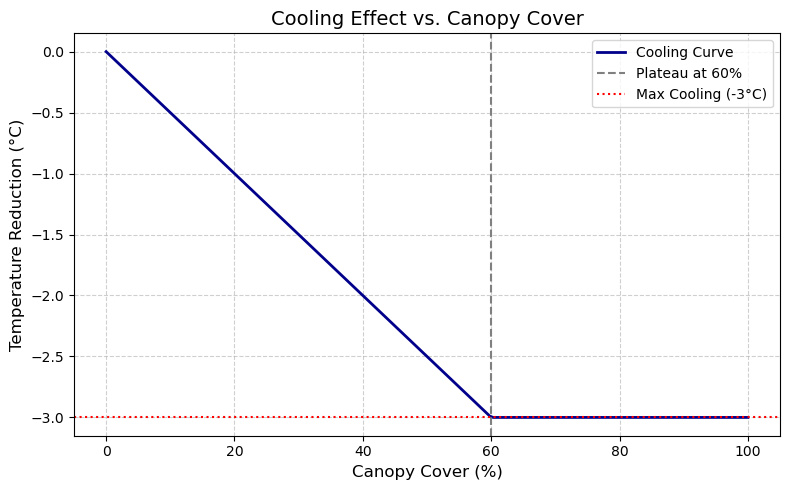

In [7]:
from utils_cb import canopy_cooling
import numpy as np

# Plot the cooling function
canopy = np.linspace(0, 100, 200) # Canopy cover from 0% to 100%
max_cooling = 3  # Max cooling temperature in °C
plateau_at = 60    # Plateau point for the cooling function in percentage
cooling = canopy_cooling(canopy, max_cooling=max_cooling, plateau_at=plateau_at) # helper function to calculate cooling effect

# Plot
plt.figure(figsize=(8, 5))
plt.plot(canopy, cooling, label='Cooling Curve', color='darkblue', linewidth=2)
plt.axvline(plateau_at, color='gray', linestyle='--', label=f'Plateau at {plateau_at}%')
plt.axhline(-max_cooling, color='red', linestyle=':', label=f'Max Cooling (-{max_cooling}°C)')

# Styling
plt.title('Cooling Effect vs. Canopy Cover', fontsize=14)
plt.xlabel('Canopy Cover (%)', fontsize=12)
plt.ylabel('Temperature Reduction (°C)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()

plt.show()


Calculat the baseline hazard given the `current` canopy level at each site

<GeoAxes: title={'center': 'VPD max intensity at each point'}>

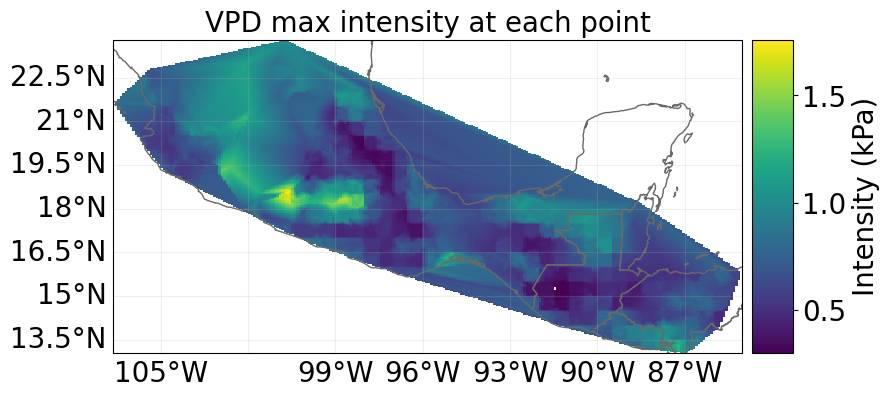

In [8]:
from utils_cb import compute_vpd_hazard

# Make a dictionary to store the hazard object for the current scenario
haz_dict = {}

# Compute the hazard using the exposure object and the ISIMIP data
if hazard_type == 'VPD':
    # Compute VPD hazard with canopy cooling
    haz_dict['current'] = compute_vpd_hazard(exp, tas_gs, hurs_gs,
                                    canopy_scenario= "current", # Canopy scenario to use. Can be set to default value of canopy cover in the exposure object
                                    cooling_fn=canopy_cooling
                                    )

# This will be our baseline hazard object for the current scenario
haz = haz_dict['current']
# plot the VPD hazard object
haz.plot_intensity(0)

## Step 4 – Get the Vulnerability

The vulnerability curve is sourced from the following study:  
[https://www.nature.com/articles/s43016-022-00614-8#MOESM1](https://www.nature.com/articles/s43016-022-00614-8#MOESM1)

This study provides a vulnerability function that links mean VPD during the growing season to yield impacts.  
- Confidence intervals are included in the paper and can be used for uncertainty analysis.
- For future applications, this vulnerability function can be replaced or calibrated using locally observed yield or production data.

##

<Axes: title={'center': 'VPD 1: VPD Empirical Yield Loss'}, xlabel='Intensity (kPa)', ylabel='Impact (%)'>

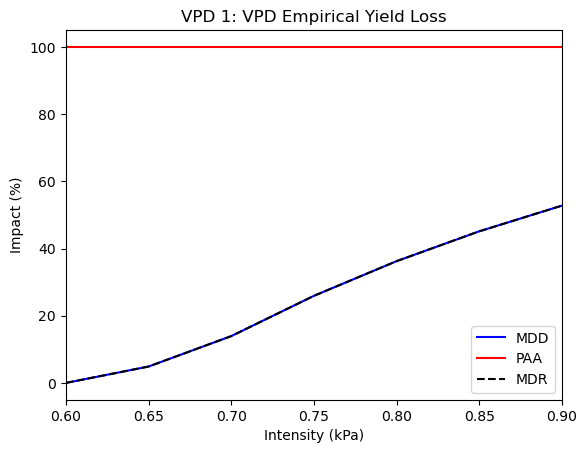

In [9]:
from utils_cb import impact_func_from_kath

impf_vpd = impact_func_from_kath(
    file_path="vpd_effect_approximation.csv",
    intensity_col="Mean_VPD_kPa",
    yield_col="Effect_Central",
    only_yield_losses=True,
    haz_type="VPD",
    unit="kPa",
    name="VPD Empirical Yield Loss"
)

impf_vpd.plot()

In [10]:
# Store the impact function in impact function set
from climada.entity import ImpactFuncSet
# Create an ImpactFuncSet with the VPD impact function

imp_fun_set = ImpactFuncSet([impf_vpd])

## Step 6 – Impact Analysis Including Uncertainty

In this step, we calculate key risk metrics such as **Average Annual Impact (AAI)** and **Return Period Losses**, while accounting for uncertainty in key model parameters. These uncertainties affect the CLIMADA objects: `Exposure`, `ImpactFunctionSet`, and `Hazard`.

We use the [UNSEQUA](https://climada-python.readthedocs.io/en/stable/tutorial/climada_engine_unsequa.html#calcimpact) module from CLIMADA, which supports stochastic simulations to explore the range of possible outcomes.

The goal is to reflect data limitations and model assumptions by estimating a range of plausible risk values.

**Current Uncertainty Variables in This Example**
- **Crop Production** (Exposure): uncertainty in spatial distribution of yields
- **Impact Function**: variation based on confidence intervals from the referenced study

We also aim to compare risk under different canopy cover conditions. Specifically, we compare current conditions with a scenario where all sites have at least a minimum level of canopy cover.

> **Note:** Due to the time required to generate hazard layers, we simplify this by manually creating two hazard sets in the code without incorporating uncertainty into the hazard itself.

**Additional Uncertainty Variables to Explore**
- **Canopy Cover** (Exposure): modifies hazard intensity through shading
- **Cooling Benefit** (Adaptation Measure): defines how much canopy cover reduces VPD


In [11]:
import copy
import scipy as sp
from functools import partial

from climada.engine.unsequa import InputVar

## Define the uncertainty variables for the exposure, impact function set, and hazard
# Exposure
exp_distr = {
    "e_value": sp.stats.uniform(0.5, 1.0), # Uniform distribution between 0.5 and 1.5 multiply with the crop productivity value
}

# Impact function set
impf_distr = {
    "i_seed": sp.stats.randint(low=1, high=1000), # Uniform distribution between 1 and 100 determines the random seed for the impact function
}


In [12]:
## Define the uncertainty functions for the exposure, impact function set and hazard
from climada.entity import ImpactFuncSet
from utils_cb import generate_random_impact_func_from_ci

# Define the base exposure
def exp_func(e_value, exp_base=exp):
    # Copy the base exposure
    exp = copy.deepcopy(exp_base)
    # Scale the value of the exposure by the e_value
    exp.gdf["value"] *= e_value
    return exp

# Impact function set
# Define the base impact function set
def impf_set_fun (i_seed):
    # Generate a random impact function from the VPD empirical yield loss
    return ImpactFuncSet([
        generate_random_impact_func_from_ci(  # helper function to generate a random impact function based on the confidence intervals of the paper 
            seed=int(i_seed),
            file_path='vpd_effect_approximation.csv',
            name='Random VPD IF'
        )
    ])

Often, we want to look at the **relative impact** compared to the **total production**. To do this, we scale the exposure values so they sum to one. This allows us to calculate the **relative contribution** of each site to the total, and then estimate the **relative impact** accordingly.


In [13]:
# Make a scaled version of the exposure function to get a normalized exposure
def exp_scaled_func(*args, **kwargs):
    exp = exp_func(*args, **kwargs)
    exp.gdf["value"] = exp.gdf["value"] / exp.gdf["value"].sum()
    return exp

Define the input uncertainty variables

In [14]:
# Uncertainty variable dicts
exp_ivs = {
    "unscaled": InputVar(exp_func, exp_distr),
    "scaled": InputVar(exp_scaled_func, exp_distr)
}

impf_iv = InputVar(impf_set_fun, impf_distr)

# Outputs split by exposure type and hazard key
output_imp = {
    "unscaled": {},
    "scaled": {}
}


To assess the benefits of increasing canopy cover, we define an alternative hazard set based on a **minimum canopy threshold** applied across all exposure points.

- For each site, if the current canopy cover is **below** the defined minimum level, we adjust it **up to the minimum**.
- If the canopy cover is **already above** the threshold, we leave it unchanged.
- The adjusted canopy cover is then used to recalculate the hazard intensity (e.g. VPD), resulting in a new hazard set.

This "Minimum Canopy Scenario" represents a simplified adaptation intervention and allows us to compare risk metrics (like AAI) under improved canopy conditions.

In [15]:
from utils_cb import compute_vpd_hazard

# Define the minimum canopy cover
min_canopy_cover = 50  # Minimum canopy cover percentage

# Name the measure 
measure_name = f"Canopy Cover {min_canopy_cover}%"

# Compute the hazard using the exposure object and the ISIMIP data
if hazard_type == 'VPD':
    # Compute VPD hazard with canopy cooling
    haz_dict[measure_name] = compute_vpd_hazard(exp, tas_gs, hurs_gs,
                                    canopy_scenario= min_canopy_cover, # Canopy scenario to use
                                    cooling_fn=canopy_cooling
                                    )

# plot the VPD hazard object
# haz.plot_intensity(0)

Derive the uncertainty metrics

In [16]:
from climada.engine.unsequa import CalcImpact

# Remove the sclaed and unscaled and include in the plot function instead
for key, haz in haz_dict.items():
    for mode in ["unscaled", "scaled"]:
        exp_iv = exp_ivs[mode]
        calc_imp = CalcImpact(exp_iv, impf_iv, haz)
        samples = calc_imp.make_sample(N=2**7, sampling_kwargs={"skip_values": 2**8})
        result = calc_imp.uncertainty(samples, rp=list(range(1, 40)))
        output_imp[mode][key] = result


We now visualize the **distribution of impacts** under the current and minimum canopy scenarios.

To estimate the **economic value** of the impacts, we assume:
- The value of crop losses corresponds to the **first stage of the value chain** (e.g. farmgate price).
- Prices are based on **current futures market estimates** for each crop.

This allows us to interpret the distribution in both **biophysical (tonnes lost)** and **monetary terms (USD lost)**, enabling a more policy-relevant cost-benefit comparison.


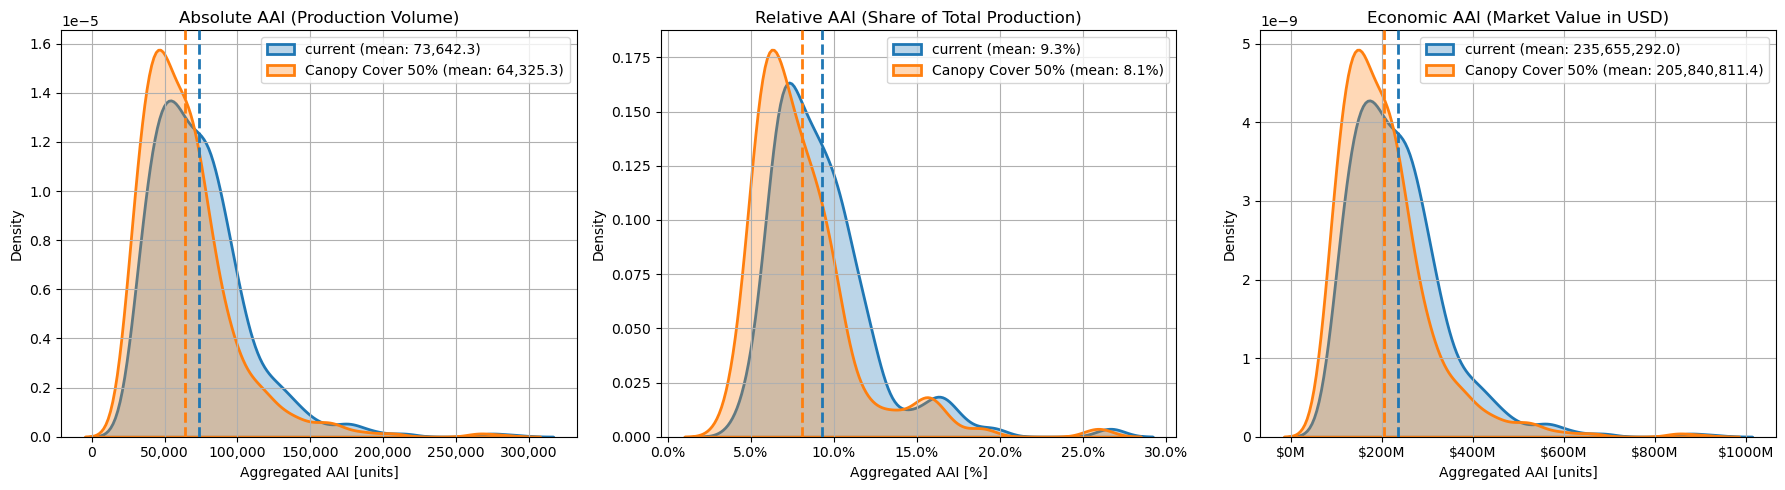

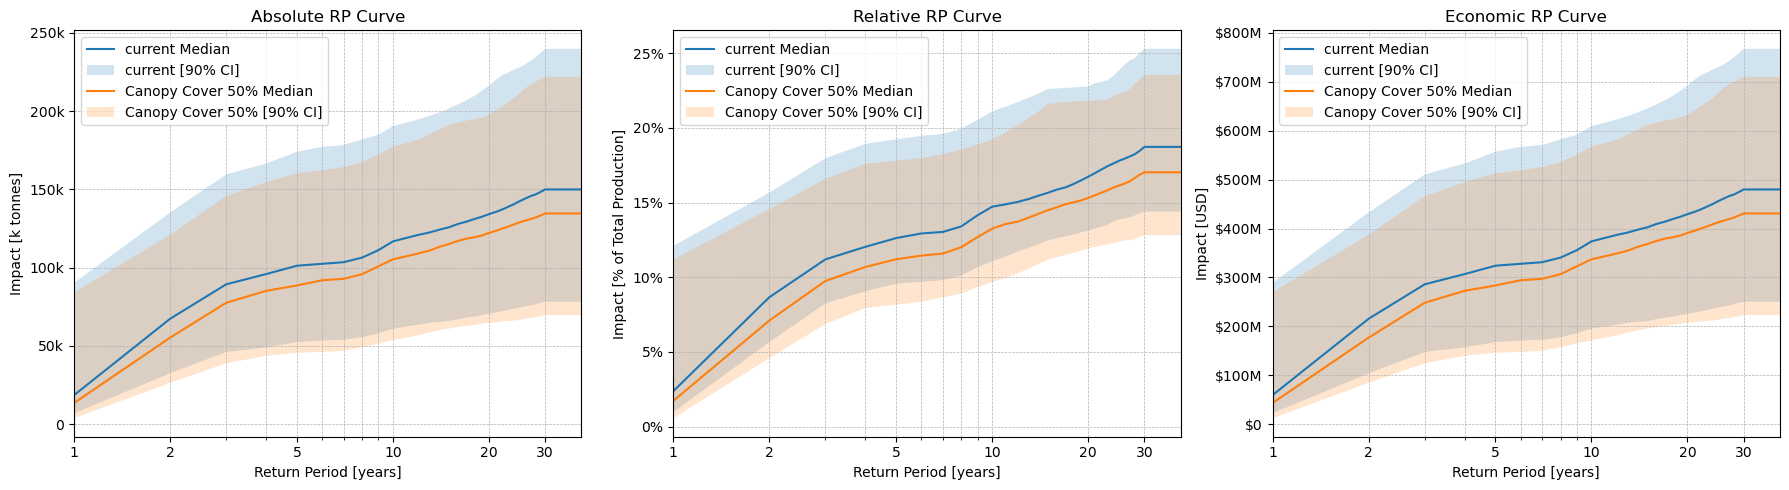

In [17]:
from utils_cb import plot_kde_and_rp_panels

price_per_ton = 3200  # Price per ton of crop for the impact calculation
plot_kde_and_rp_panels(output_imp, price_per_ton)


### Sensitivity Analysis – What Drives the Variation?

To better understand what drives uncertainty in the impact estimates, we perform a **sensitivity analysis**.

This analysis helps identify which input parameters (e.g. exposure, impact function, hazard) contribute the most to the variation in results.  
By quantifying their influence, we can:

- Prioritize **which variables need better data** to reduce uncertainty,
- Guide **future data collection efforts**, and
- Improve model confidence and decision-making relevance.

For example:
- If **crop exposure** (production values) explains most of the variation, then better spatial yield data is needed.
- If the **impact function** is highly sensitive, we may need more locally calibrated vulnerability curves.
- If **canopy-modified hazard** is a key driver, better canopy cover maps or climate-canopy interaction models should be prioritized.

This step helps shift from just quantifying uncertainty to **managing it through targeted improvements** in model inputs.


## Step 6 – Define the Adaptation Measures 

Here we define the measures. 
In this set up we only compare measures of different shade levels

In [18]:
# Define the minimum canopy cover
min_canopy = [40, 60]  # Minimum canopy cover percentage
n_years = 20 # Number of years for the investment

# Define shared canopy cost parameters
canopy_cost_params = {
    "setup_cost_per_ha": 300,
    "annual_maint_cost_per_ha": 30,
    "duration_years": n_years,  # Duration of the investment in years
}

Define the measures

In [19]:
from climada.entity.measures import Measure, MeasureSet
from utils_cb import compute_additional_canopy_cost

# Create a meaure set to store the measures
meas_set = MeasureSet()

# For each canopy cover percentage, define the measure by computing the hazard and cost
for canopy in min_canopy:
    # Compute the hazard using the exposure object and the ISIMIP data
    if hazard_type == 'VPD':
        # Compute VPD hazard with canopy cooling
        haz_meas = compute_vpd_hazard(exp, tas_gs, hurs_gs,
                                        canopy_scenario= canopy, # Canopy scenario to use
                                        cooling_fn=canopy_cooling
                                        )
        # Save the hazard to the output directory
        haz_file = OUTPUT_DIR / f"haz_vpd_{canopy}.h5"
        haz_meas.write_hdf5(haz_file)
        print(f"Stored hazard {canopy} in {OUTPUT_DIR / f'haz_vpd_{canopy}.h5'}")
    
    # Define the measure
    meas =  Measure(
        name= f"Canopy Cover {canopy}%", # Name of the measure
        haz_type = hazard_type,
        # Give the measure a random color
        color_rgb = np.random.rand(3,),
        cost = compute_additional_canopy_cost(exp, min_canopy_percent=canopy, **canopy_cost_params)[0],
        hazard_set = haz_file  # Path to the hazard file
    )
    
    # Append the measure to the measure set
    meas_set.append(meas)
    meas_set.check()

Stored hazard 40 in /Users/viggo/Documents/Programming/Consult/UNU/output/haz_vpd_40.h5
Stored hazard 60 in /Users/viggo/Documents/Programming/Consult/UNU/output/haz_vpd_60.h5


## Step 7 - Cost Benefit

- Cost (Measure)
- Current crop production (Entity - Present)
- Growth of future crops production (Entity - Future)

Define the discount rate.

<Axes: title={'center': 'Discount rates'}, xlabel='Year', ylabel='discount rate (%)'>

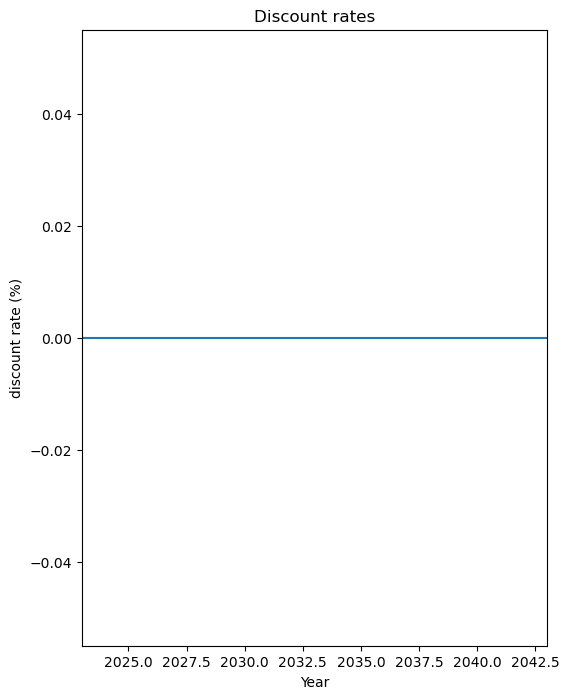

In [20]:
from climada.entity import DiscRates


CURRENT_YEAR = 2023  # Current year for the discount rate calculation

# Create a range of years for the discount rate
FUTURE_YEAR = CURRENT_YEAR + n_years  # Future year for the discount rate calculation
year_range = np.arange(CURRENT_YEAR, FUTURE_YEAR + 1) # Create an array of years from the current year to the future year
annual_discount = np.zeros(n_years +1)  # Create an array of zeros for the discount rates
disc_base = DiscRates(year_range, annual_discount)

# Plot the discount rates
disc_base.plot()

Define the uncertainty variables

In [21]:
ent_today_distr = {"e_value": sp.stats.uniform(0.7, 1),
                   "m_cost": sp.stats.uniform(0.5, 1)
                   }

ent_future_distr = {"e_growth": sp.stats.uniform(0.7, 1)
                     }

Define the uncertainty variable functions

In [22]:
import copy
from climada.entity import Entity

exp_fut_base = copy.deepcopy(exp)  # Create a base copy of the exposure object for the future entity
exp_fut_base.ref_year = FUTURE_YEAR  # Set the reference year for the future exposure

# Entity today has an uncertainty in the total asset value
def ent_today_func(e_value, m_cost, # The uncertainty parameters
                   exp_base=exp, impf_func_base=imp_fun_set, measure_set_base=meas_set, disc_base=disc_base # The base objects to copy and modify
                   ):
    # Copy the base objects
    exp = copy.deepcopy(exp_base)
    exp.ref_year = CURRENT_YEAR # Set the reference year for the exposure
    impf_func_set = copy.deepcopy(impf_func_base)
    meas_set = copy.deepcopy(measure_set_base)
    disc_rate = copy.deepcopy(disc_base)


    # Scale the value of the exposure by the e_value
    exp.gdf["value"] *= e_value

    # Scale the cost of the measure by the m_cost
    for meas in measure_set_base.get_measure(hazard_type):
        meas.cost *= m_cost

    # Create the entity
    return Entity(  exposures=exp,
                    impact_func_set=impf_func_set,
                    measure_set=meas_set,
                    disc_rates= disc_rate
                )

# Entity future has an uncertainty in the growth of the asset value
def ent_future_func(
    e_growth,  # Uncertainty parameter: asset value growth factor
    exp_fut_base=exp_fut_base,
    impf_func_base=ImpactFuncSet([impf_vpd]),
    measure_set_base=meas_set,
    disc_base=disc_base
):
    # Copy base inputs
    exp = copy.deepcopy(exp_fut_base)
    impf_func_set = copy.deepcopy(impf_func_base)
    meas_set = copy.deepcopy(measure_set_base)
    disc_rate = copy.deepcopy(disc_base)

    # Scale exposure value based on growth factor
    exp.gdf["value"] *= e_growth
    exp.ref_year = FUTURE_YEAR  # Make sure ref_year is set

    # Create and return future entity
    return Entity(
        exposures=exp,
        impact_func_set=impf_func_set,
        measure_set=meas_set,
        disc_rates=disc_rate
    )


Define  the  ... 

In [23]:
import scipy as sp
from climada.engine.unsequa import InputVar
from climada.engine.unsequa import CalcCostBenefit


unc_cb = CalcCostBenefit(
    haz_input_var=haz,
    ent_input_var=InputVar(ent_today_func, ent_today_distr),
    haz_fut_input_var = None,
    ent_fut_input_var = InputVar(ent_future_func, ent_future_distr)
    )


In [24]:
output_cb = unc_cb.make_sample(N=10^2, sampling_kwargs={"calc_second_order": False})
output_cb.get_samples_df().tail()

,e_value,m_cost,e_growth
35,0.91875,1.34375,0.79375
36,1.23125,1.34375,0.79375
37,0.91875,0.90625,0.79375
38,0.91875,1.34375,1.29375
39,1.23125,0.90625,1.29375


In [25]:
# without pool
output_cb = unc_cb.uncertainty(output_cb)




Measure             Cost (tonnes )    Benefit (tonnes )    Benefit/Cost
----------------  ----------------  -------------------  --------------
Canopy Cover 40%       4.44048e+07             -78527.7     -0.00176845
Canopy Cover 60%       1.4502e+08                   0        0

--------------------  --------  ---------
Total climate risk:   844992    (tonnes )
Average annual risk:   47926.5  (tonnes )
Residual risk:        923520    (tonnes )
--------------------  --------  ---------
Net Present Values

Measure             Cost (tonnes )    Benefit (tonnes )    Benefit/Cost
----------------  ----------------  -------------------  --------------
Canopy Cover 40%       4.30172e+07             -78527.7      -0.0018255
Canopy Cover 60%       1.40488e+08                  0         0

--------------------  --------  ---------
Total climate risk:   844992    (tonnes )
Average annual risk:   47926.5  (tonnes )
Residual risk:        923520    (tonnes )
--------------------  --------  --------

Make distirbution plots of Total risk & benefit, cost, benfit/cost, 

In [26]:
print(tabulate(output_cb.get_uncertainty().head(), headers='keys', tablefmt='psql'))
print(output_cb.get_uncertainty().columns)
print(meas_set.get_names(hazard_type))

# Figure 1 - (1x3) subplots
# risk = Average annual risk (AAR) of the hazard
# risk - future = Average annual risk (AAR) of the hazard in the future
# tot_climate_risk = Net present value of the total climate risk

# Figure 2 - (1x3) subplots
# cost_meas = Total cost of the measures (NPV)
# Benef = Total benefit of the measures (NPV)
# CostBen = Cost-benefit ratio of the measures (NPV)

+----+-------------------------------+--------------------------------------+------------------------------------+-----------------------------------+-------------------------------------+--------------------------------------------+------------------------------------------+-----------------------------------------+-------------------------------------+--------------------------------------------+------------------------------------------+-----------------------------------------+------------------------------+-------------------------------------+-----------------------------------+----------------------------------+------------------------------------+-------------------------------------------+-----------------------------------------+----------------------------------------+------------------------------------+-------------------------------------------+-----------------------------------------+----------------------------------------+--------------------+-------------------------

In [27]:
def print_summary_statistics(df, measure_names):
    """
    Print mean and 90% confidence intervals for AAI (present, future),
    total climate risk, and cost-benefit metrics for each measure.
    """
    from tabulate import tabulate

    def summarize(col):
        data = df[col].dropna()
        mean = data.mean()
        ci_lower = data.quantile(0.05)
        ci_upper = data.quantile(0.95)
        return mean, ci_lower, ci_upper

    rows = []

    # --- AAI Risk Summary ---
    base_present = "no measure - risk - present"
    base_future = "no measure - risk - future"
    rows.append(["AAI (Present)", "No measure", *summarize(base_present)])
    rows.append(["AAI (Future)", "No measure", *summarize(base_future)])

    for meas in measure_names:
        rows.append(["AAI (Present)", meas, *summarize(f"{meas} - risk - present")])
        rows.append(["AAI (Future)", meas, *summarize(f"{meas} - risk - future")])

    # --- Total Climate Risk ---
    rows.append(["Total Climate Risk", "All", *summarize("tot_climate_risk")])

    # --- Cost, Benefit, Cost-Benefit Ratio ---
    for meas in measure_names:
        rows.append(["Cost (NPV)", meas, *summarize(f"{meas} - cost_meas - future")])
        rows.append(["Benefit (NPV)", meas, *summarize(f"{meas} Benef")])
        rows.append(["Cost-Benefit", meas, *summarize(f"{meas} CostBen")])

    # --- Display table ---
    print(tabulate(rows, headers=["Metric", "Scenario", "Mean", "5th Percentile", "95th Percentile"], floatfmt=".2f"))

# Print summary statistics for the output DataFrame
measure_names = meas_set.get_names(hazard_type)
print_summary_statistics(output_cb.get_uncertainty(), measure_names)

Metric              Scenario                  Mean    5th Percentile    95th Percentile
------------------  ----------------  ------------  ----------------  -----------------
AAI (Present)       No measure            49464.20          32420.83           68429.75
AAI (Future)        No measure            50489.37          32548.98           68429.75
AAI (Present)       Canopy Cover 40%      54061.06          35433.80           74789.13
AAI (Future)        Canopy Cover 40%      55181.49          35573.86           74789.13
AAI (Present)       Canopy Cover 60%      49464.20          32420.83           68429.75
AAI (Future)        Canopy Cover 60%      50489.37          32548.98           68429.75
Total Climate Risk  All                 1049512.44         737349.74         1275561.29
Cost (NPV)          Canopy Cover 40%   31283681.90        2776390.16        92511544.41
Benefit (NPV)       Canopy Cover 40%     -97534.35        -118541.75          -68524.13
Cost-Benefit        Canopy Cover

/Users/viggo/miniforge3/envs/climada_env/lib/python3.11/site-packages/numpy/lib/function_base.py:4655: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
/Users/viggo/miniforge3/envs/climada_env/lib/python3.11/site-packages/numpy/lib/function_base.py:4655: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


In [28]:
def plot_kde_panel(df, column_map, *, suptitle=None, value_format="${:,.0f}", figsize=(18, 5)):
    """
    General function for plotting 1xN KDE subplots from a dict of label → [columns].

    Parameters:
    - df: DataFrame with data
    - column_map: OrderedDict or dict: subplot_title -> [(label, column_name)]
    - value_format: formatter for mean values in legend
    - suptitle: optional string
    - figsize: tuple for figure size
    """
    import matplotlib.pyplot as plt
    import seaborn as sns

    n_subplots = len(column_map)
    fig, axs = plt.subplots(1, n_subplots, figsize=figsize, sharey=False)
    if n_subplots == 1:
        axs = [axs]

    palette = sns.color_palette("Set1", n_colors=10)

    for ax, (title, entries) in zip(axs, column_map.items()):
        for i, (label, col) in enumerate(entries):
            if col in df.columns:
                val = df[col].dropna()
                if val.var() > 0:
                    mean_val = val.mean()
                    label_with_mean = f"{label} (mean: {value_format.format(mean_val)})"
                    sns.kdeplot(val, ax=ax, label=label_with_mean,
                                fill=True, color=palette[i], linewidth=2, alpha=0.3)
                    ax.axvline(mean_val, color=palette[i], linestyle="--")
        ax.set_title(title)
        ax.set_xlabel("Value")
        ax.set_ylabel("Density")
        ax.grid(True)
        ax.legend()

    if suptitle:
        fig.suptitle(suptitle, fontsize=16)
    plt.tight_layout()
    plt.show()


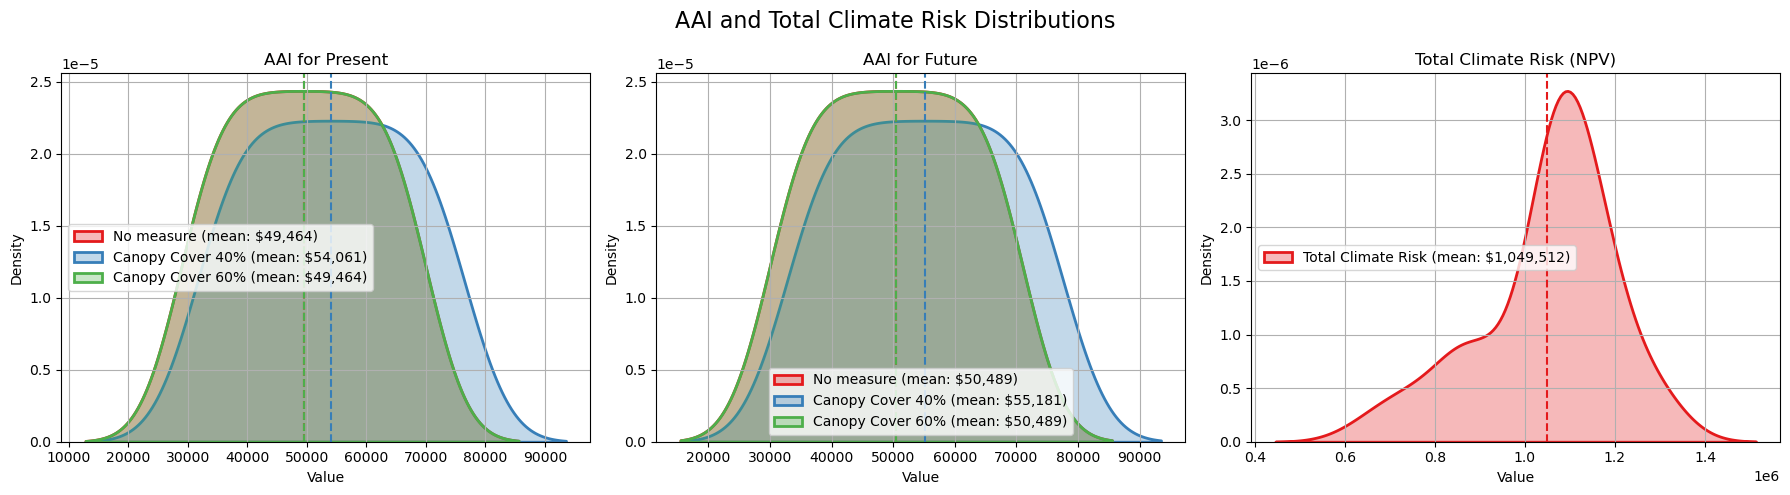

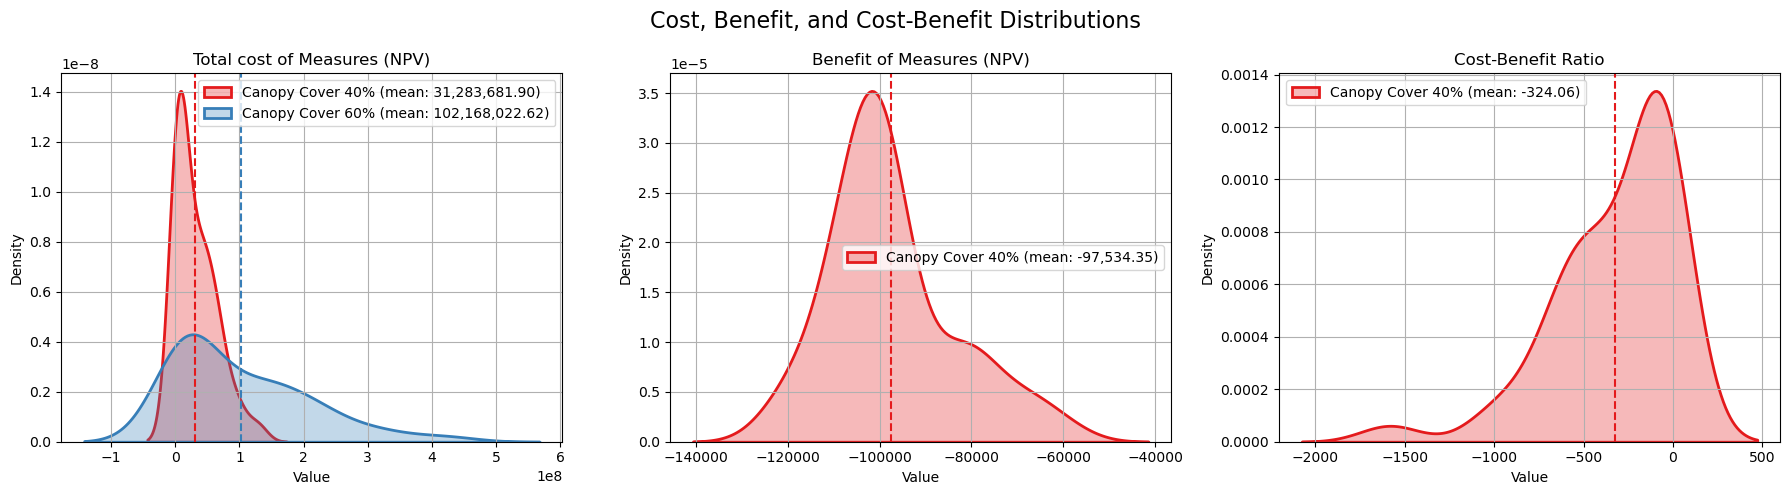

In [29]:
from collections import OrderedDict

# Define the columns to plot for each subplot


column_map = OrderedDict({
    "AAI for Present": [("No measure", "no measure - risk - present")] + [(meas, f"{meas} - risk - present") for meas in measure_names],
    "AAI for Future":  [("No measure", "no measure - risk - future")]  + [(meas, f"{meas} - risk - future") for meas in measure_names],
    "Total Climate Risk (NPV)": [("Total Climate Risk", "tot_climate_risk")]
})

plot_kde_panel(output_cb.get_uncertainty(), column_map, suptitle="AAI and Total Climate Risk Distributions")

column_map_cb = OrderedDict({
    "Total cost of Measures (NPV)": [(meas, f"{meas} - cost_meas - future") for meas in measure_names],
    "Benefit of Measures (NPV)": [(meas, f"{meas} Benef") for meas in measure_names],
    "Cost-Benefit Ratio": [(meas, f"{meas} CostBen") for meas in measure_names],
})

plot_kde_panel(output_cb.get_uncertainty(), column_map_cb, suptitle="Cost, Benefit, and Cost-Benefit Distributions", value_format="{:,.2f}")
